<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Linear_Regression_Return_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas_ta

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# --- 1. DATA LOADING ---
tickers = ['AAPL', 'SPY']
start_date = '2020-01-01'
end_date = '2024-01-01'

data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Handle MultiIndex if present
if isinstance(data.columns, pd.MultiIndex):
    # Depending on yfinance version, structure varies.
    # We want 'Close' and 'Volume' for both tickers.
    # Let's flatten or extract explicitly.
    df = pd.DataFrame()
    df['AAPL_Close'] = data['Close']['AAPL']
    df['SPY_Close'] = data['Close']['SPY']
    df['AAPL_Volume'] = data['Volume']['AAPL']
else:
    # Older yfinance structure
    df = data[['Close', 'Volume']].copy() # Simplified logic needed if columns differ

/tmp/ipython-input-2491777827.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)


In [ ]:
# --- 2. FEATURE ENGINEERING ---
# We are building X (Features) to predict Y (Target)

returns = pd.DataFrame()
returns['AAPL_Ret'] = np.log(df['AAPL_Close'] / df['AAPL_Close'].shift(1))
returns['SPY_Ret']  = np.log(df['SPY_Close'] / df['SPY_Close'].shift(1))
returns['AAPL_Vol_Change'] = np.log(df['AAPL_Volume'] / df['AAPL_Volume'].shift(1))

df_model = returns.dropna().copy()

# DEFINE TARGET (Y): Next Day's Return
# We shift returns BACKWARDS by 1.
# The return at t+1 becomes the target for row t.
df_model['Target'] = df_model['AAPL_Ret'].shift(-1)

# DEFINE FEATURES (X): Today's info
# 1. Momentum (Today's AAPL return)
# 2. Market Sentiment (Today's SPY return)
# 3. Liquidity/Attention (Volume Change)
feature_cols = ['AAPL_Ret', 'SPY_Ret', 'AAPL_Vol_Change']

# Drop the last row because it has no target (NaN after shift)
df_model = df_model.dropna()

In [ ]:
# --- 3. TRAIN / TEST SPLIT (CRITICAL STEP) ---
# In Finance, we CANNOT shuffle. We must split by time.
# Train on 2020-2022, Test on 2023
split_index = int(len(df_model) * 0.8)

X = df_model[feature_cols]
y = df_model['Target']

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples:  {len(X_test)}")

Training Samples: 803
Testing Samples:  201


In [ ]:
# --- 4. LINEAR REGRESSION MODEL ---
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

In [ ]:
# --- 5. EVALUATION ---
# The R-squared metric tells us how much variance we explained.
r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)

print(f"\nModel Coefficients:")
for feat, coef in zip(feature_cols, model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept (Alpha): {model.intercept_:.6f}")

print(f"\nR-Squared (Train): {r2_train:.5f}")
print(f"R-Squared (Test):  {r2_test:.5f}")


Model Coefficients:
  AAPL_Ret: -0.0192
  SPY_Ret: -0.2270
  AAPL_Vol_Change: -0.0007
  Intercept (Alpha): 0.001001

R-Squared (Train): 0.02873
R-Squared (Test):  -0.03629


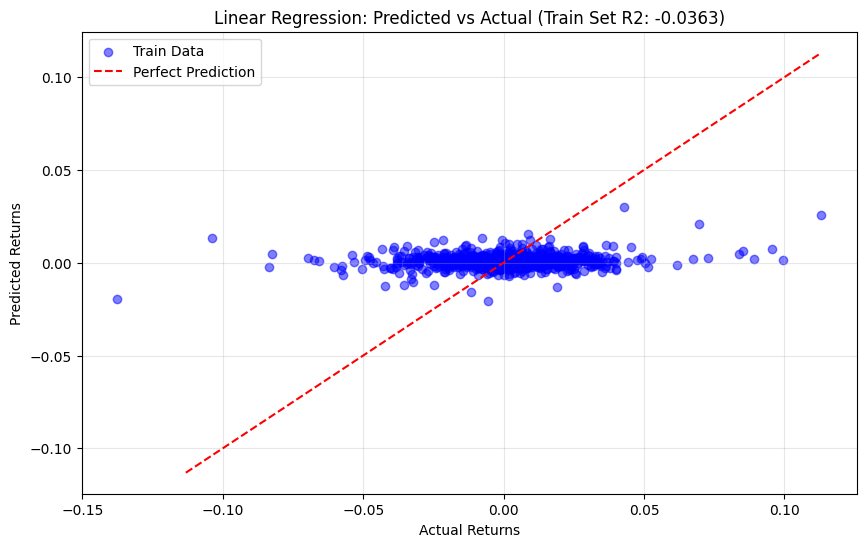

In [ ]:
# --- 6. VISUALIZATION ---
# Plot 1: Predicted vs Actual (Scatter)
plt.figure(figsize=(10, 6))
plt.scatter(y_train, pred_train, alpha=0.5, color='blue', label='Train Data')

# Perfect prediction line
limit = max(y_train.max(), pred_train.max())
plt.plot([-limit, limit], [-limit, limit], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title(f"Linear Regression: Predicted vs Actual (Train Set R2: {r2_test:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

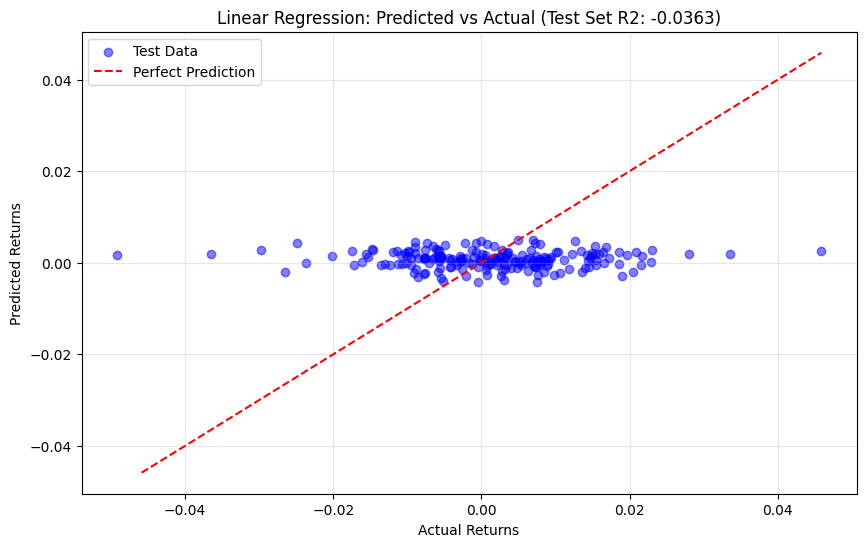

In [ ]:
# --- 6. VISUALIZATION ---
# Plot 1: Predicted vs Actual (Scatter)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_test, alpha=0.5, color='blue', label='Test Data')

# Perfect prediction line
limit = max(y_test.max(), pred_test.max())
plt.plot([-limit, limit], [-limit, limit], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title(f"Linear Regression: Predicted vs Actual (Test Set R2: {r2_test:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

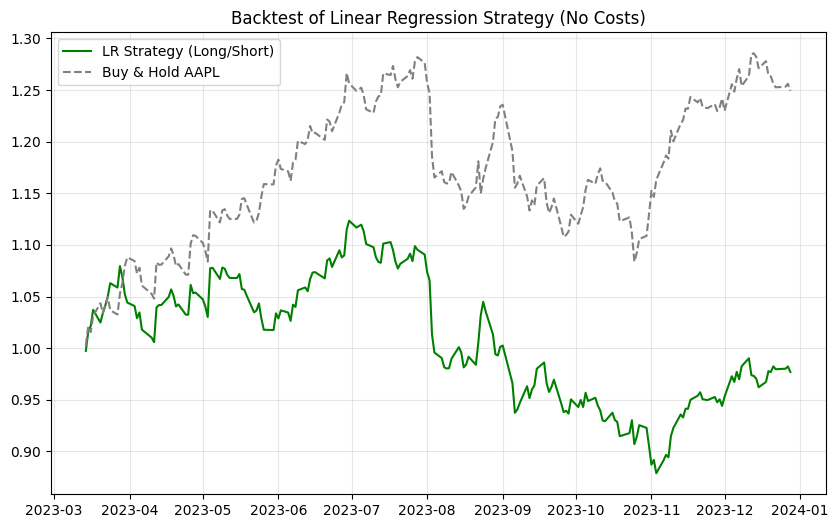

In [ ]:
# Plot 2: Cumulative Returns of a Simple Strategy based on the Model
# Strategy: If Model predicts > 0, Buy (Long). If < 0, Sell (Short).
# Note: This ignores transaction costs!
signal = np.sign(pred_test)
strategy_returns = signal * y_test
cum_strategy = (1 + strategy_returns).cumprod()
cum_buy_hold = (1 + y_test).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(cum_strategy.index, cum_strategy, label='LR Strategy (Long/Short)', color='green')
plt.plot(cum_buy_hold.index, cum_buy_hold, label='Buy & Hold AAPL', color='gray', linestyle='--')
plt.title("Backtest of Linear Regression Strategy (No Costs)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# REGULARIZED LINEAR MODELS

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [ ]:
# --- 1. DATA LOADING (Using Real Data) ---
ticker = 'AAPL'
market = 'SPY'
df = yf.download([ticker, market], start='2018-01-01', end='2024-01-01', progress=False)['Close']

/tmp/ipython-input-3859971550.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download([ticker, market], start='2018-01-01', end='2024-01-01', progress=False)['Close']


In [ ]:
# --- 2. ADVANCED FEATURE ENGINEERING ---
data = pd.DataFrame()
data['Target'] = np.log(df[ticker] / df[ticker].shift(1)).shift(-1) # Next Day Return

# Features (Today's Info)
data['Ret_L1'] = np.log(df[ticker] / df[ticker].shift(1))   # 1-day lag
data['Ret_L5'] = np.log(df[ticker] / df[ticker].shift(5))   # 5-day momentum
data['Mkt_Ret'] = np.log(df[market] / df[market].shift(1))  # Market correlation

# Add Volatility (Rolling Std Dev)
data['Vol_10'] = data['Ret_L1'].rolling(10).std()

data.dropna(inplace=True)

In [ ]:
# --- 3. SCALING & SPLITTING ---
X = data[['Ret_L1', 'Ret_L5', 'Mkt_Ret', 'Vol_10']]
y = data['Target']

# Split
split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Standardization (CRITICAL)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- 4. MODELING (Using Ridge to handle Multicollinearity) ---
# Ridge adds a small penalty to keep coefficients from exploding
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
# --- 5. EVALUATION ---
train_preds = model.predict(X_train_scaled)
print(f"New Train R2: {r2_score(y_train, train_preds):.4f}")

New Train R2: 0.0265


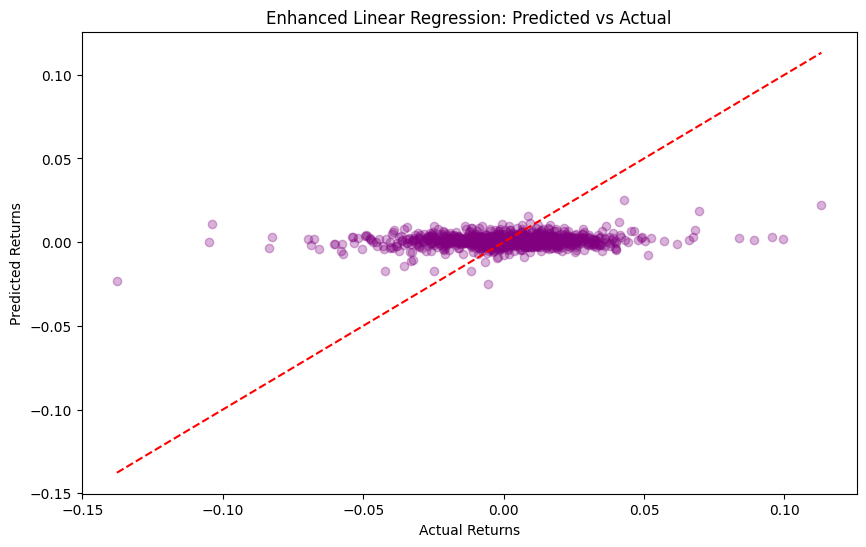

In [ ]:
# --- 6. VISUALIZING THE CHANGE ---
plt.figure(figsize=(10, 6))
plt.scatter(y_train, train_preds, alpha=0.3, color='purple', label='Enhanced Model')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.title("Enhanced Linear Regression: Predicted vs Actual")
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.show()

# Testing Regularization

Checking to see if Lasso Regularization kills any features

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# --- 1. DATA SETUP (Real Data: NVDA is a high-signal stock) ---
# We use NVDA because its volatility often provides more "spread" for the model
df = yf.download(['NVDA', 'QQQ'], start='2020-01-01', end='2024-01-01', progress=False)['Close']

data = pd.DataFrame()
data['Target'] = np.log(df['NVDA'] / df['NVDA'].shift(1)).shift(-1)
data['NVDA_Ret'] = np.log(df['NVDA'] / df['NVDA'].shift(1))
data['QQQ_Ret'] = np.log(df['QQQ'] / df['QQQ'].shift(1))
data['Volat_5d'] = data['NVDA_Ret'].rolling(5).std()
data.dropna(inplace=True)

/tmp/ipython-input-1392425550.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(['NVDA', 'QQQ'], start='2020-01-01', end='2024-01-01', progress=False)['Close']


In [ ]:
# --- 2. PREPROCESSING ---
X = data[['NVDA_Ret', 'QQQ_Ret', 'Volat_5d']]
y = data['Target']

# Scale features so penalty is applied fairly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# --- 3. MODEL COMPARISON ---
# Alpha is the 'lambda' (strength of penalty)
lasso = Lasso(alpha=0.001)
lasso.fit(X_scaled, y)

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)

Ridge()

In [ ]:
# --- 4. THE REVEAL: COEFFICIENTS ---
print("Lasso Coefficients (L1 - Feature Selection):")
for feat, coef in zip(X.columns, lasso.coef_):
    print(f"{feat}: {coef:.6f}")

print("\nRidge Coefficients (L2 - Shrinkage):")
for feat, coef in zip(X.columns, ridge.coef_):
    print(f"{feat}: {coef:.6f}")

Lasso Coefficients (L1 - Feature Selection):
NVDA_Ret: -0.000000
QQQ_Ret: -0.003942
Volat_5d: -0.000117

Ridge Coefficients (L2 - Shrinkage):
NVDA_Ret: 0.002861
QQQ_Ret: -0.007356
Volat_5d: -0.001295


# MORE ROBUST LINEAR MODEL WITH ADDITIONAL FEATURES

/tmp/ipython-input-3388744238.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(list(assets.values()), start='2018-01-01', end='2024-01-01', progress=False)


Test Set R-Squared: -0.03756
Directional Accuracy: 47.99%


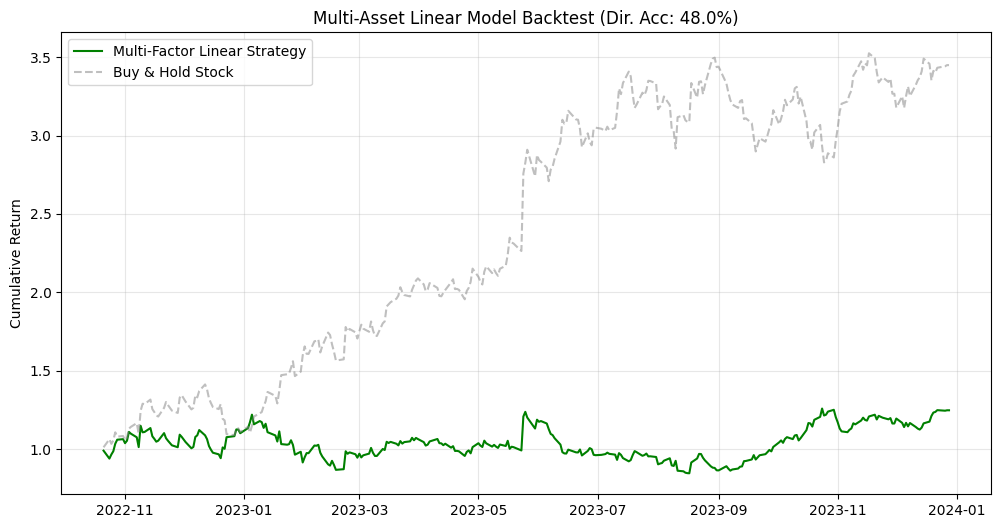

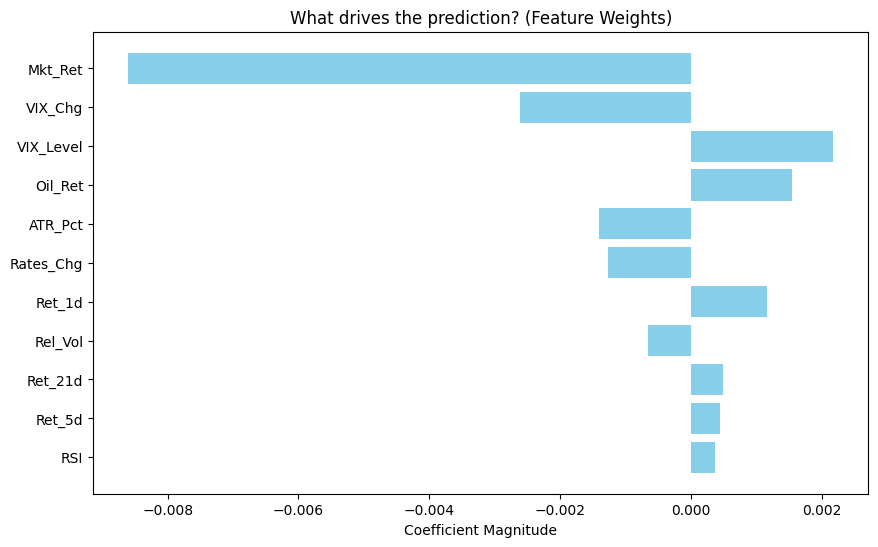

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score
import matplotlib.pyplot as plt

# --- 1. DATA INGESTION (THE KITCHEN SINK) ---
# We define a dictionary of tickers to map them to friendly names
assets = {
    'Stock': 'NVDA',
    'Market': 'SPY',
    'Rates': '^TNX',   # 10-Year Treasury Yield
    'VIX': '^VIX',     # Volatility Index
    'Oil': 'CL=F'      # Crude Oil
}

print("Downloading Multi-Asset Data...")
df_raw = yf.download(list(assets.values()), start='2018-01-01', end='2024-01-01', progress=False)

# Handle MultiIndex columns (flattening)
# Structure is usually df['Close']['NVDA'] -> We want a flat DataFrame
df = pd.DataFrame()
for friendly_name, ticker in assets.items():
    if isinstance(df_raw.columns, pd.MultiIndex):
        # Extract Close price for each asset
        df[friendly_name] = df_raw['Close'][ticker]

        # For the main stock, we also want Volume/High/Low for technicals
        if friendly_name == 'Stock':
            df['Stock_Vol'] = df_raw['Volume'][ticker]
            df['Stock_High'] = df_raw['High'][ticker]
            df['Stock_Low'] = df_raw['Low'][ticker]
    else:
        # Fallback for simple index
        df = df_raw['Close'].copy() # Simplified logic

# Drop any rows where data is missing (e.g., Oil might trade on holidays when Stocks don't)
df.dropna(inplace=True)

# --- 2. ADVANCED FEATURE ENGINEERING ---
features = pd.DataFrame(index=df.index)

# A. The Target: Next Day's Log Return of the Stock
features['Target'] = np.log(df['Stock'] / df['Stock'].shift(1)).shift(-1)

# B. Auto-Regressive Features (Price History)
# Lags: What happened yesterday? 1 week ago?
features['Ret_1d'] = np.log(df['Stock'] / df['Stock'].shift(1))
features['Ret_5d'] = np.log(df['Stock'] / df['Stock'].shift(5))
features['Ret_21d'] = np.log(df['Stock'] / df['Stock'].shift(21))

# C. Technical Indicators (Momentum & Volatility)
# RSI (Mean Reversion)
features['RSI'] = ta.rsi(df['Stock'], length=14)
# ATR Ratio (Volatility relative to price)
features['ATR_Pct'] = ta.atr(df['Stock_High'], df['Stock_Low'], df['Stock'], length=14) / df['Stock']
# Relative Volume (Attention)
features['Rel_Vol'] = df['Stock_Vol'] / df['Stock_Vol'].rolling(20).mean()

# D. MACRO FEATURES (The "All Data Sources" part)
# 1. Rates Change: If Yields go UP, Tech usually goes DOWN (Correlation check)
features['Rates_Chg'] = df['Rates'].diff()

# 2. VIX Level & Change: High VIX = Fear
features['VIX_Level'] = df['VIX']
features['VIX_Chg'] = df['VIX'].pct_change()

# 3. Oil Returns: Inflation proxy
features['Oil_Ret'] = df['Oil'].pct_change()

# 4. Market Beta: Correlation to SPY
features['Mkt_Ret'] = np.log(df['Market'] / df['Market'].shift(1))

# Drop NaNs created by rolling windows/diffs
features.dropna(inplace=True)

# --- 3. MODEL TRAINING ---
# Split Train/Test
split_idx = int(len(features) * 0.8)
train_df = features.iloc[:split_idx]
test_df = features.iloc[split_idx:]

X_train = train_df.drop('Target', axis=1)
y_train = train_df['Target']
X_test = test_df.drop('Target', axis=1)
y_test = test_df['Target']

# Scaling (Crucial when mixing Percentages, Dollars, and Index Levels)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression (Linear + L2 Penalty to handle correlated macro factors)
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# Predictions
pred_test = model.predict(X_test_scaled)

# --- 4. EVALUATION & BACKTEST ---
# Metric 1: R-Squared (Predictive Power)
r2 = r2_score(y_test, pred_test)
print(f"Test Set R-Squared: {r2:.5f}")

# Metric 2: Directional Accuracy (Did we get the Sign right?)
# Sign of prediction vs Sign of actual
pred_sign = np.sign(pred_test)
actual_sign = np.sign(y_test)
accuracy = accuracy_score(actual_sign, pred_sign)
print(f"Directional Accuracy: {accuracy*100:.2f}%")

# Metric 3: Cumulative Returns (The "Money" Chart)
# Strategy: If Pred > 0, Buy. If Pred < 0, Short (or Cash).
# We assume we trade at the CLOSE of the day the prediction is made (requires agility)
# or Open of next day. For simplicity here: Position * Actual Return.
strategy_returns = pred_sign * y_test
cum_strat = (1 + strategy_returns).cumprod()
cum_hold = (1 + y_test).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_strat, label='Multi-Factor Linear Strategy', color='green')
plt.plot(cum_hold, label='Buy & Hold Stock', color='gray', linestyle='--', alpha=0.5)
plt.title(f"Multi-Asset Linear Model Backtest (Dir. Acc: {accuracy*100:.1f}%)")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. FEATURE IMPORTANCE ---
# Let's see what the model actually cared about
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Weight': model.coef_})
coef_df = coef_df.sort_values(by='Weight', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='skyblue')
plt.title("What drives the prediction? (Feature Weights)")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis() # Highest weight on top
plt.show()